In [19]:
import zipfile
import cv2
import numpy as np
import os
from PIL import Image

from google.colab import drive
from google.colab.patches import cv2_imshow

In [20]:
drive.mount('/content/drive')
source_image_path = '/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/'
file_name = 'mehul'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
zip_object = zipfile.ZipFile(file=os.path.join(source_image_path, file_name + '.zip'), mode='r')
zip_object.extractall(os.path.join(source_image_path, file_name))
zip_object.close()

In [22]:
def get_image_data(store_path):
  paths = [os.path.join(store_path, f) for f in os.listdir(store_path) if f.endswith('.jpg')]
  faces = []
  ids = []
  for path in paths:
    print(path)
    image = Image.open(path).convert('L')
    image_np = np.array(image, 'uint8')
    image_id = int(path.split('.')[1])
    
    ids.append(image_id)
    faces.append(image_np)
  
  return np.array(ids), faces

In [23]:
ids, faces = get_image_data(os.path.join(source_image_path, file_name))

/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/mehul/person.1.1.jpg
/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/mehul/person.1.10.jpg
/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/mehul/person.1.11.jpg
/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/mehul/person.1.12.jpg
/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/mehul/person.1.13.jpg
/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/mehul/person.1.14.jpg
/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/mehul/person.1.15.jpg
/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/mehul/person.1.16.jpg
/content/drive/My

In [24]:
lbph_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_classifier.train(faces, ids)
lbph_classifier.write(os.path.join(source_image_path, 'lbph_mehul_classifier.yml'))

In [25]:
image = Image.open(os.path.join(source_image_path, file_name, 'person.1.1.jpg'))
image.size

(220, 220)

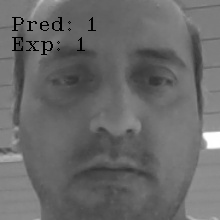

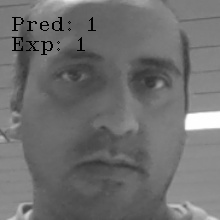

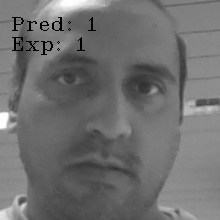

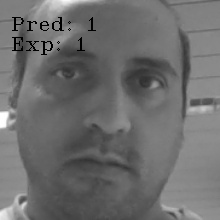

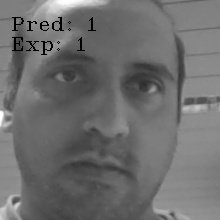

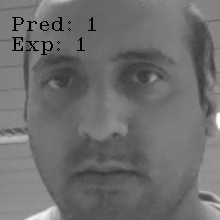

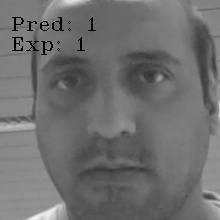

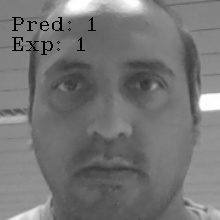

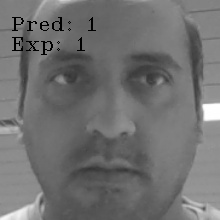

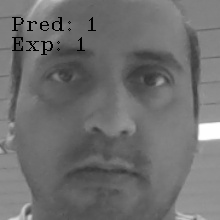

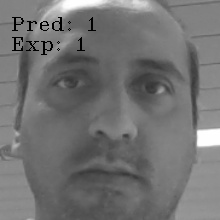

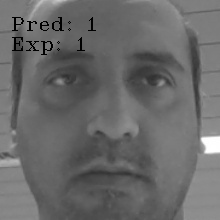

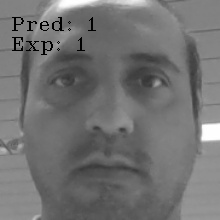

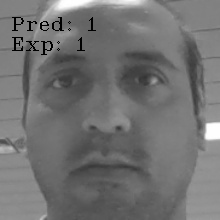

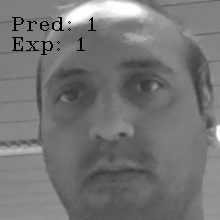

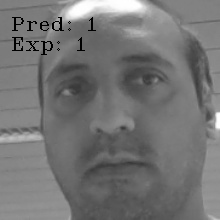

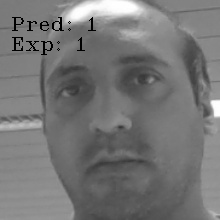

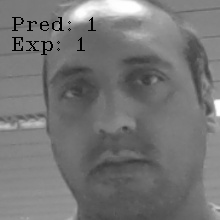

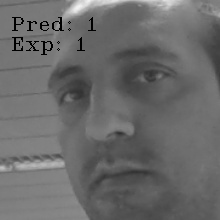

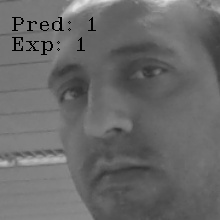

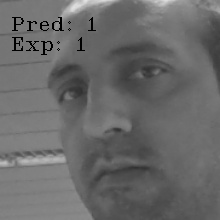

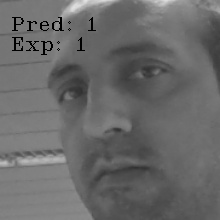

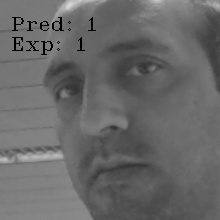

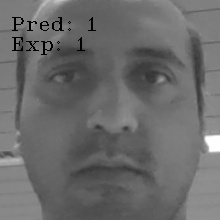

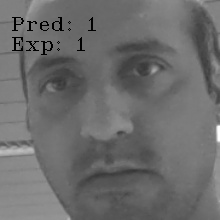

In [26]:
paths = [os.path.join(source_image_path, file_name, f) for f in os.listdir(os.path.join(source_image_path, file_name)) if f.endswith('.jpg')]
for path in paths:
  image = Image.open(path).convert('L')
  image_np = np.array(image, 'uint8')
  prediction, _ = lbph_classifier.predict(image_np)
  expected_output = int(path.split('.')[1])

  cv2.putText(image_np, 'Pred: ' + str(prediction), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
  cv2.putText(image_np, 'Exp: ' + str(expected_output), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
  cv2_imshow(image_np)